<a href="https://colab.research.google.com/github/mclaramoorais/pipeline-ml-colab/blob/main/C%C3%B3pia_de_ATIVIDADE_PIPELINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE


In [ ]:
# Upload do arquivo no Colab: # from google.colab import files
# uploaded = files.upload() df = pd.read_excel('/content/creditcard-csv2.xlsx')

In [ ]:
df = pd.read_excel('/content/creditcard-csv2.xlsx')

print("Dataset carregado com sucesso!")

Dataset carregado com sucesso!


In [ ]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
print("PRIMEIRAS LINHAS:")
print(df.head())

print("\nINFORMAÇÕES DO DATASET:")
print(df.info())

print("\nVALORES NULOS:")
print(df.isnull().sum())

PRIMEIRAS LINHAS:
   Time               V1               V2               V3               V4  \
0     0  -13598071336738 -727811733098497  253634673796914  137815522427443   
1     0  119185711131486   26615071205963   16648011335321  448154078460911   
2     1 -135835406159823 -134016307473609  177320934263119  379779593034328   
3     1 -966271711572087 -185226008082898  179299333957872 -863291275036453   
4     2 -115823309349523  877736754848451    1548717846511  403033933955121   

                V5               V6               V7               V8  \
0 -338320769942518  462387777762292  239598554061257  986979012610507   
1  600176492822243 -823608088155687 -788029833323113  851016549148104   
2 -503198133318193  180049938079263  791460956450422  247675786588991   
3 -103088796030823  124720316752486   23760893977178  377435874652262   
4 -407193377311653  959214624684256  592940745385545 -270532677192282   

                V9  ...              V21              V22           

In [ ]:
print("\nCOLUNAS:")
print(df.columns)

# Variável alvo
target = 'Class'

print("\nVARIÁVEL ALVO:")
print(target)


COLUNAS:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

VARIÁVEL ALVO:
Class



QUANTIDADE DE CLASSES:
Class
0    284315
1       492
Name: count, dtype: int64

PORCENTAGEM:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


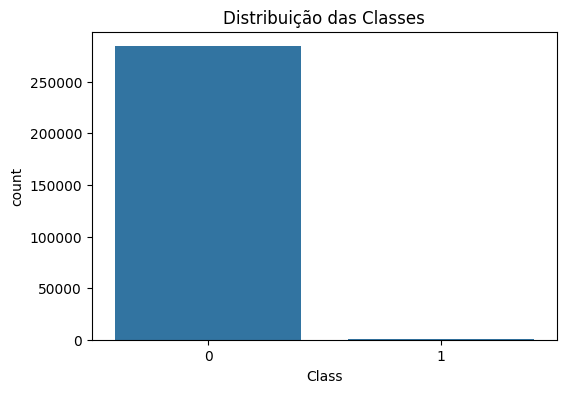

In [ ]:
print("\nQUANTIDADE DE CLASSES:")
print(df['Class'].value_counts())

print("\nPORCENTAGEM:")
print(df['Class'].value_counts(normalize=True) * 100)

# Gráfico
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Distribuição das Classes')
plt.show()

In [ ]:
print("\nRESUMO ESTATÍSTICO DO DATASET:")
print(df.describe())


RESUMO ESTATÍSTICO DO DATASET:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575 -7.505882e+13  2.340342e+13  3.729228e+13 -1.009763e+13   
std     47488.145955  3.834315e+14  4.611949e+14  4.172914e+14  4.445690e+14   
min         0.000000 -9.999911e+14 -9.999968e+14 -9.999929e+14 -9.999950e+14   
25%     54201.500000 -2.795382e+14 -2.477925e+14 -1.929493e+14 -2.507382e+14   
50%     84692.000000  1.964756e+12  2.875949e+13  8.055800e+13 -1.045030e+13   
75%    139320.500000  1.731548e+14  2.785837e+14  2.323576e+14  2.691586e+14   
max    172792.000000  9.999867e+14  9.999845e+14  9.999856e+14  9.999910e+14   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean  -2.004330e+13 -1.135441e+14  2.008460e+13  3.819159e+13 -1.991807e+13   
std    4.5

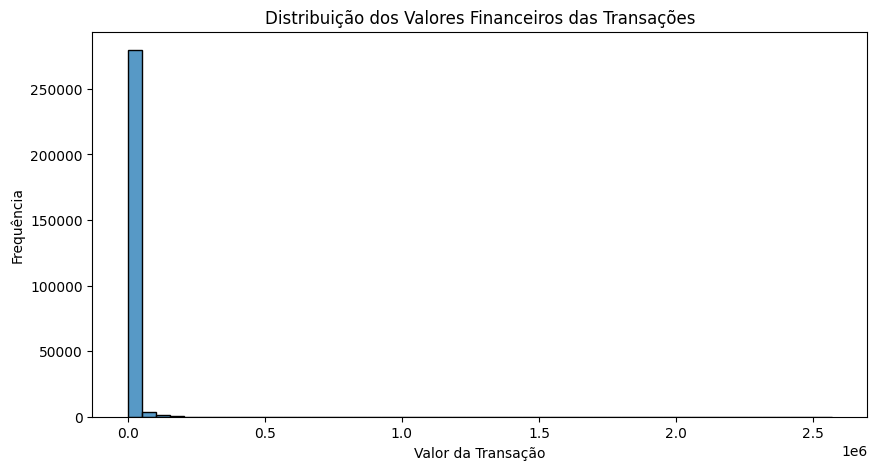

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50)

plt.title('Distribuição dos Valores Financeiros das Transações')
plt.xlabel('Valor da Transação')
plt.ylabel('Frequência')

plt.show()

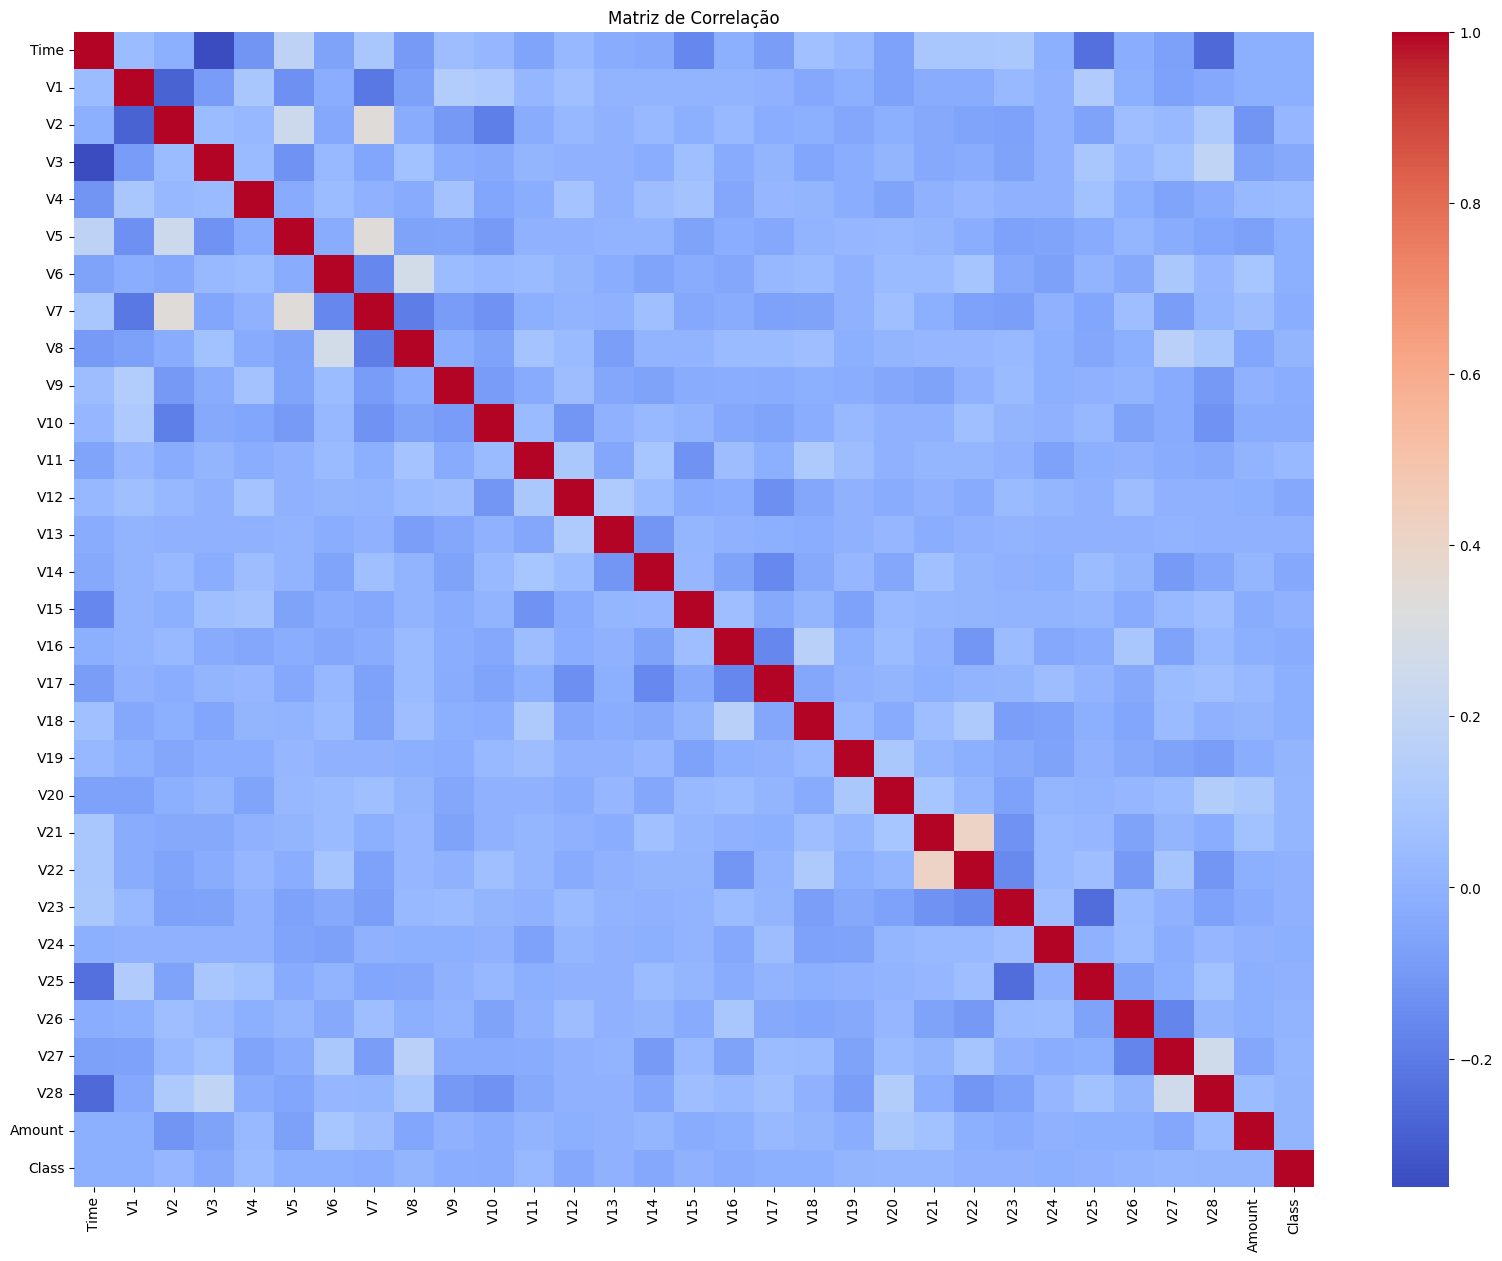

In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Aplicação da padronização na variável Amount
df['Amount_Normalized'] = scaler.fit_transform(df[['Amount']])

# Remoção da coluna original após a transformação
df.drop('Amount', axis=1, inplace=True)

print("Padronização da variável Amount realizada com sucesso.")

Padronização da variável Amount realizada com sucesso.


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nDIVISÃO DOS DADOS REALIZADA COM SUCESSO")
print(f"Conjunto de Treinamento: {X_train.shape}")
print(f"Conjunto de Teste: {X_test.shape}")


DIVISÃO DOS DADOS REALIZADA COM SUCESSO
Conjunto de Treinamento: (227845, 30)
Conjunto de Teste: (56962, 30)


In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAntes do SMOTE:")
print(y_train.value_counts())

print("\nApós o SMOTE:")
print(y_train_smote.value_counts())


Antes do SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Após o SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
log_model = LogisticRegression(max_iter=1000)

# Treinamento do modelo
log_model.fit(X_train_smote, y_train_smote)

# Predições
y_pred_log = log_model.predict(X_test)

In [ ]:
print("\n=== LOGISTIC REGRESSION ===")

acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print(f"Accuracy: {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall: {rec_log:.4f}")
print(f"F1-Score: {f1_log:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


=== LOGISTIC REGRESSION ===
Accuracy: 0.6215
Precision: 0.0043
Recall: 0.9490
F1-Score: 0.0086

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.62      0.77     56864
           1       0.00      0.95      0.01        98

    accuracy                           0.62     56962
   macro avg       0.50      0.78      0.39     56962
weighted avg       1.00      0.62      0.76     56962



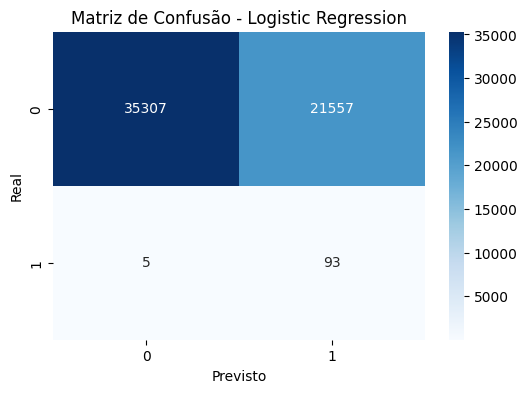

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Matriz de Confusão - Logistic Regression')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest treinado com sucesso!")

Random Forest treinado com sucesso!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("\n=== RANDOM FOREST ===")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


=== RANDOM FOREST ===
Accuracy: 0.9993
Precision: 0.8684
Recall: 0.6735
F1-Score: 0.7586

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.67      0.76        98

    accuracy                           1.00     56962
   macro avg       0.93      0.84      0.88     56962
weighted avg       1.00      1.00      1.00     56962



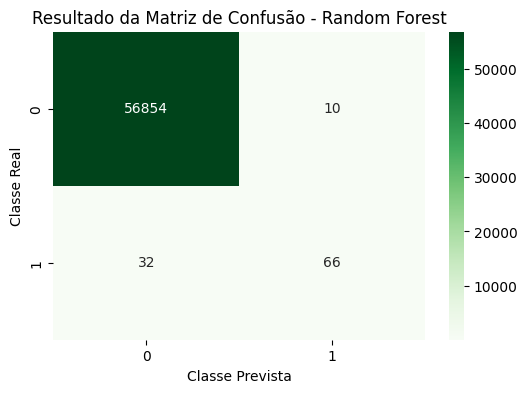

In [ ]:
matriz_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    matriz_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Resultado da Matriz de Confusão - Random Forest')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')

plt.show()

In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_log, acc_rf],
    'Precision': [prec_log, prec_rf],
    'Recall': [rec_log, rec_rf],
    'F1-Score': [f1_log, f1_rf]
})

print("\nCOMPARAÇÃO DOS MODELOS:")
print(resultados)


COMPARAÇÃO DOS MODELOS:
                Modelo  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.621467   0.004296  0.948980  0.008553
1        Random Forest  0.999263   0.868421  0.673469  0.758621


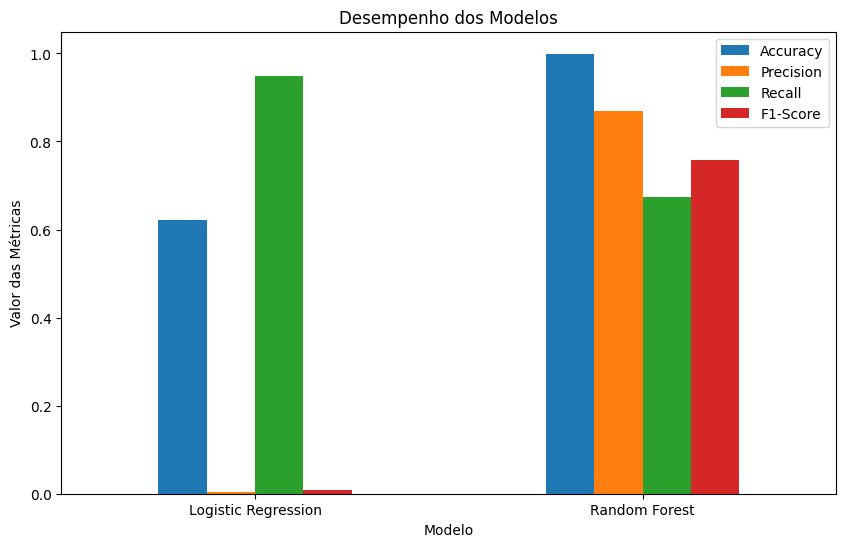

In [ ]:
resultados.set_index('Modelo').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Desempenho dos Modelos')
plt.ylabel('Valor das Métricas')
plt.xticks(rotation=0)

plt.show()

In [ ]:
train_score = rf_model.score(X_train_smote, y_train_smote)
test_score = rf_model.score(X_test, y_test)

print("\n===== ANÁLISE DO MODELO =====")

print(f"Acurácia no Treino: {train_score:.4f}")
print(f"Acurácia no Teste: {test_score:.4f}")

if (train_score - test_score) > 0.05:
    print("\nIndícios de Overfitting.")
else:
    print("\nBoa capacidade de generalização.")


===== ANÁLISE DO MODELO =====
Acurácia no Treino: 1.0000
Acurácia no Teste: 0.9993

Boa capacidade de generalização.


In [ ]:
print("\n===== CONCLUSÃO =====")

if rec_rf > rec_log:
    print("O Random Forest apresentou melhor Recall.")
    print("Isso indica maior capacidade de identificar fraudes.")
else:
    print("A Logistic Regression apresentou melhor Recall.")
    print("Isso indica maior capacidade de identificar fraudes.")

print("\nEm sistemas de fraude, o Recall é extremamente importante.")
print("Fraudes não detectadas geram prejuízo financeiro.")
print("Porém, a Precision também deve ser considerada para evitar muitos falsos positivos.")


===== CONCLUSÃO =====
A Logistic Regression apresentou melhor Recall.
Isso indica maior capacidade de identificar fraudes.

Em sistemas de fraude, o Recall é extremamente importante.
Fraudes não detectadas geram prejuízo financeiro.
Porém, a Precision também deve ser considerada para evitar muitos falsos positivos.
